# Sequnece Model Practice

- Conv1d + LSTM 기반 주가 예측 확장 실습:
 `Open`, `High`, `Low`, `Close`, `Volume`과 파생 feature를 함께 사용해 다변량 시계열 데이터를 구성한다.

## 1. 라이브러리 불러오기

필요한 라이브러리를 불러온다. `FinanceDataReader`가 설치되어 있지 않다면 아래 설치 코드를 먼저 실행한다.

In [54]:
# %pip install finance-datareader

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import FinanceDataReader as fdr

## 2. 데이터 불러오기

In [56]:
# 종목 코드 설정
naver_code = '035420'

# TODO: FinanceDataReader를 사용하여 네이버 주가 데이터를 가져오기
naver = fdr.DataReader(naver_code)

naver.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2014-02-06,144203,152013,143602,148009,428072,NaN
2014-02-07,150413,151214,146407,150413,186951,0.016242
2014-02-10,150010,150811,147007,147008,132548,-0.022638
2014-02-11,147809,149612,146607,147609,98646,0.004088
2014-02-12,148810,149210,146406,148410,68665,0.005426


In [57]:
# 데이터 기본 정보 확인
# TODO: 데이터의 행/열 개수, 결측치 개수, 최근 5개 행을 확인하기
print(naver.shape)
print(naver.isnull().sum())
naver.head(5)

(3000, 6)
Open      0
High      0
Low       0
Close     0
Volume    0
Change    1
dtype: int64


,Open,High,Low,Close,Volume,Change
Date,,,,,,
2014-02-06,144203,152013,143602,148009,428072,NaN
2014-02-07,150413,151214,146407,150413,186951,0.016242
2014-02-10,150010,150811,147007,147008,132548,-0.022638
2014-02-11,147809,149612,146607,147609,98646,0.004088
2014-02-12,148810,149210,146406,148410,68665,0.005426


## 3. feature 구성

다음 feature를 사용한다.

- `Open`: 시가
- `High`: 고가
- `Low`: 저가
- `Close`: 종가
- `Volume`: 거래량
- `MA5`: 5일 이동평균
- `MA20`: 20일 이동평균
- `Return`: 일별 수익률
- `Range`: 하루 변동폭 비율

정답값 `target`은 다음 날의 `Close`이다.

In [58]:
# 원본 데이터 복사
stock_df = naver.copy()

# TODO: 5일 이동평균 MA5 생성
stock_df['MA5'] = stock_df['Close'].rolling(window=5).mean()

# TODO: 20일 이동평균 MA20 생성
stock_df['MA20'] = stock_df['Close'].rolling(window=20).mean()
 
# TODO: 일별 수익률 Return 생성
stock_df['Return'] = stock_df['Close'].pct_change()

# TODO: 하루 변동폭 비율 Range 생성
stock_df['Range'] = ((stock_df['High'] - stock_df['Low']) / stock_df['Close'].shift(1)) * 100

# TODO: 결측치 제거
stock_df = stock_df.dropna()

stock_df.head()

,Open,High,Low,Close,Volume,Change,MA5,MA20,Return,Range
Date,,,,,,,,,,
2014-03-05,166836,171643,166235,170642,149905,0.036499,164072.4,151414.30,0.036499,3.284882
2014-03-06,176248,176248,166635,167437,205735,-0.018782,165834.8,152385.70,-0.018782,5.633431
2014-03-07,168236,170039,165033,165434,122436,-0.011963,166195.2,153136.75,-0.011963,2.989781
2014-03-10,166836,171643,166235,170842,132318,0.032690,167797.6,154328.45,0.032690,3.268977
2014-03-11,173045,175649,168238,170241,110850,-0.003518,168919.2,155460.05,-0.003518,4.337926


In [59]:
# 사용할 feature 목록
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'MA20', 'Return', 'Range']
target_col = 'Close'

# TODO: feature 데이터와 target 데이터를 분리하기
features = stock_df[feature_cols]

target = stock_df[target_col]

print(features.shape)
print(target.shape)

(2981, 9)
(2981,)


## 4. 스케일링

feature와 target은 값의 범위가 다르다. 예를 들어 거래량은 가격보다 훨씬 큰 값을 가진다. 따라서 feature와 target을 각각 스케일링한다.


In [60]:
# TODO: feature용 scaler와 target용 scaler를 각각 생성하기
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# TODO: feature와 target 각각 스케일링하기
features_scaled = feature_scaler.fit_transform(features)
target_scaled = target_scaler.fit_transform(target.values.reshape(-1,1))

print(features_scaled.shape)
print(target_scaled.shape)

(2981, 9)
(2981, 1)


## 5. 다변량 시계열 학습 데이터 생성

`window_size=20`이면 과거 20일의 여러 feature를 입력으로 사용하고, 그 다음 날의 종가를 정답으로 사용한다.

생성되는 입력 shape은 다음과 같다.

```text
X: (샘플 개수, window_size, feature 수)
y: (샘플 개수, 1)
```


In [61]:
def create_multivariate_dataset(features, target, window_size=20):
    X, y = [], []

    # TODO: 과거 window_size일의 feature를 입력 X로 만들고,
    #       그 다음 날의 target을 y로 만들기
    for i in range(len(features) - window_size):
        # i번째 시점부터 window_size 개만큼의 데이터를 입력 값으로 사용
        inputs = features[i: i + window_size]
        # 입력 구간 바로 다음 시점의 값을 정답 값으로 사용
        labels = target[i + window_size]

        X.append(inputs)
        y.append(labels)
    
    return np.array(X), np.array(y)


window_size = 20
X, y = create_multivariate_dataset(features_scaled, target_scaled, window_size)

print(X.shape)
print(y.shape)

(2961, 20, 9)
(2961, 1)


## 6. Tensor 변환 및 학습/검증 분리

시계열 데이터는 순서가 중요하므로 무작위 분리하지 않고 앞쪽 80%를 학습 데이터, 뒤쪽 20%를 검증 데이터로 사용한다.


In [62]:
# TODO: X, y를 torch tensor로 변환하기
X_tensor = torch.tensor(X,dtype=torch.float32)
y_tensor = torch.tensor(y,dtype=torch.float32)

# TODO: 앞쪽 80%를 학습 데이터로 사용하기
train_size = int(len(X_tensor) * 0.8)
X_train, X_val = X_tensor.split([train_size, len(X_tensor) - train_size])
y_train, y_val = y_tensor.split([train_size, len(y_tensor) - train_size])

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

torch.Size([2368, 20, 9]) torch.Size([2368, 1])
torch.Size([593, 20, 9]) torch.Size([593, 1])


## 7. Conv1d + LSTM 모델 정의

`input_size`는 feature 개수이다. 
즉 `Open`, `High`, `Low`, `Close`, `Volume`, `MA5`, `MA20`, `Return`, `Range`를 사용하면 `input_size=9`가 된다.

Conv1d는 `(batch_size, channel, seq_len)` 형태를 요구한다. 하지만 LSTM용 데이터는 `(batch_size, seq_len, feature 수)` 형태이므로 `permute()`가 필요하다.

In [63]:
class StockConvLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, conv_filters, conv_kernel_size):
        super().__init__()

        # TODO: Conv1d 레이어 정의하기
        # in_channels는 입력 feature 수이다.
        # out_channels는 Conv1d가 만들어낼 특징 수이다.
        self.conv1d = nn.Conv1d(
            input_size,
            conv_filters,
            kernel_size=conv_kernel_size
        )

        # TODO: LSTM 레이어 정의하기
        # LSTM의 input_size는 conv_filters가 된다.
        self.lstm = nn.LSTM(
            conv_filters,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        # x: (batch_size, seq_len, input_size)

        # TODO: Conv1d 입력 형태로 변환하기
        x = x.permute(0,2,1)

        # TODO: Conv1d 적용하기
        x = self.conv1d(x)

        # TODO: LSTM 입력 형태로 다시 변환하기
        x = x.permute(0,2,1)

        # TODO: LSTM 적용 후 마지막 hidden state 사용하기
        _, (hidden, _) = self.lstm(x)

        output = self.fc1(hidden[-1])
        output = self.relu(output)
        output = self.fc2(output)
        return output

## 8. 모델 생성 및 학습

`input_size`는 feature 개수인 `len(feature_cols)`로 설정한다.


In [64]:
# TODO: 모델 생성하기
# input_size는 len(feature_cols)이다.
model = StockConvLSTM(input_size=len(feature_cols),
                  hidden_size=64,
                  num_layers=2,
                  conv_filters=32,
                  conv_kernel_size=5)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
batch_size = 32
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_train.size(0))
    train_loss = 0

    for i in range(0, X_train.size(0), batch_size):
        indices = permutation[i:i + batch_size]
        batch_X = X_train[indices]
        batch_y = y_train[indices]

        # TODO: 예측, 손실 계산, 역전파, 파라미터 업데이트 작성하기
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / X_train.size(0)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        # TODO: 검증 데이터 손실 계산하기
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)
        pass

    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss.item():.6f}')

Epoch [10/50], Train Loss: 0.000016, Val Loss: 0.000575
Epoch [20/50], Train Loss: 0.000008, Val Loss: 0.000336
Epoch [30/50], Train Loss: 0.000006, Val Loss: 0.000242
Epoch [40/50], Train Loss: 0.000007, Val Loss: 0.000277
Epoch [50/50], Train Loss: 0.000006, Val Loss: 0.000231


## 9. 예측 결과 복원 및 시각화

모델 출력은 스케일링된 값이다. 실제 주가 단위로 해석하려면 `target_scaler.inverse_transform()`을 사용해 복원해야 한다.


In [65]:
model.eval()
with torch.no_grad():
    # TODO: 검증 데이터 예측하기
    pred_scaled = model(X_val)

# TODO: 예측값과 실제값을 원래 주가 단위로 복원하기
pred_inverse = target_scaler.inverse_transform(pred_scaled.detach().numpy())
y_val_inverse = target_scaler.inverse_transform(y_val.detach().numpy())

print(pred_inverse[:5].flatten())
print(y_val_inverse[:5].flatten())

[202881.97 201742.7  201483.19 203460.56 205925.17]
[201999.98 202500.   204499.98 207500.   205499.98]


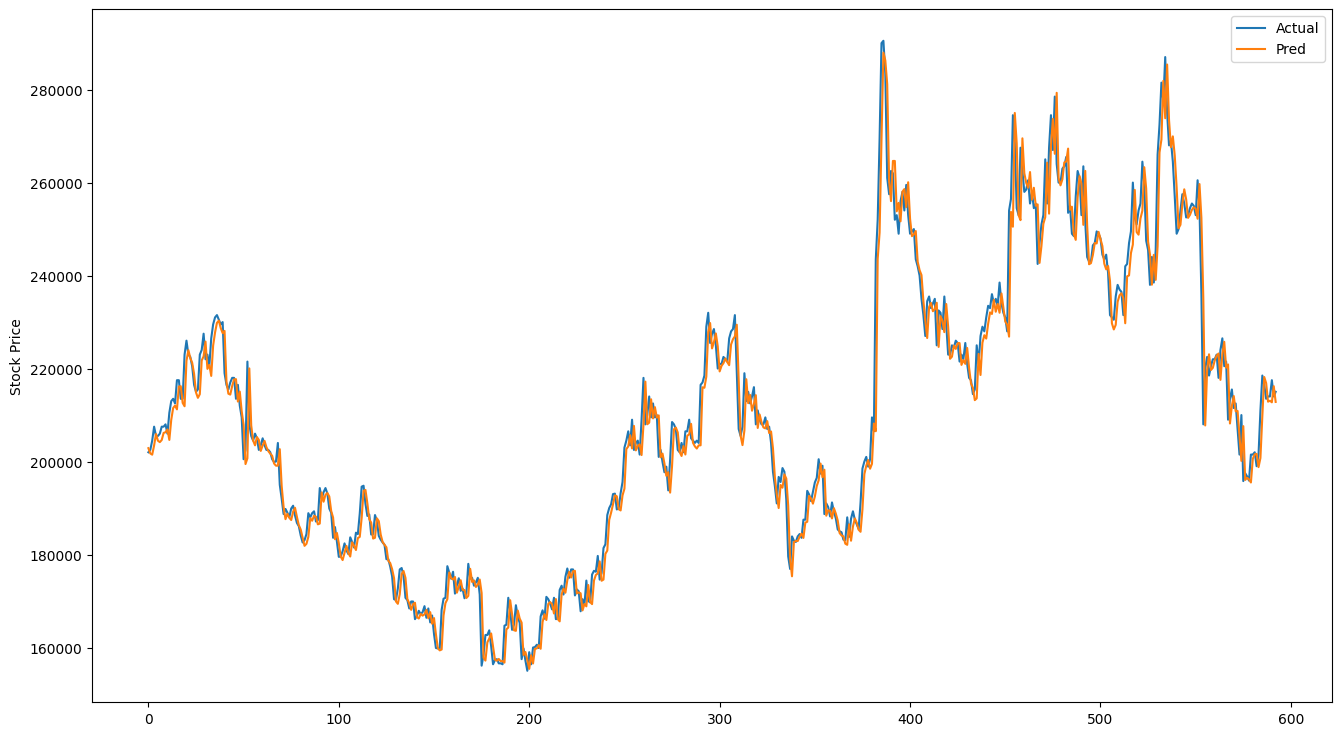

In [66]:
# TODO: 실제값과 예측값을 선 그래프로 비교하기
plt.figure(figsize=(16, 9))
plt.plot(y_val_inverse, label='Actual')
plt.plot(pred_inverse, label='Pred')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [67]:
# TODO: MAE, RMSE 계산하기
mae = mean_absolute_error(y_val_inverse,pred_inverse)
rmse = np.sqrt(mean_squared_error(y_val_inverse,pred_inverse))

print('MAE:', mae)
print('RMSE:', rmse)

MAE: 3612.483642578125
RMSE: 5491.274533293706


## 10. 다음 날 종가 예측 함수 만들기

최근 `window_size`일의 feature 데이터를 입력받아 다음 날 종가를 예측하는 함수를 만든다.


In [68]:
def predict_next_close(stock_df, model, feature_cols, feature_scaler, target_scaler, window_size=20):
    # 최근 window_size일의 feature만 사용
    # TODO: feature 데이터 추출
    recent_features = stock_df[feature_cols].iloc[-window_size:]

    # TODO: feature 스케일링
    recent_scaled = feature_scaler.transform(recent_features)

    # TODO: tensor 변환
    input_tensor = torch.tensor(recent_scaled,dtype=torch.float32).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        # TODO: 모델 예측
        pred_scaled = model(input_tensor).detach().numpy()
        

    # TODO: 예측값 역스케일링
    pred_inverse = target_scaler.inverse_transform(pred_scaled.reshape(-1,1))

    return pred_inverse[0, 0]


# TODO: 다음 날 종가 예측 실행하기
next_price = predict_next_close(
    stock_df=stock_df,
    model=model,
    feature_cols=feature_cols,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    window_size=20
)
print(next_price)

214326.5
